## Random Forest Classifier

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [77]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [78]:
x = df.drop('Outcome',axis=1)
y = df['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
RF = RandomForestClassifier(criterion='entropy',random_state=42,n_estimators=51)
RF.fit(x_train,y_train)
y_pred = RF.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



[]

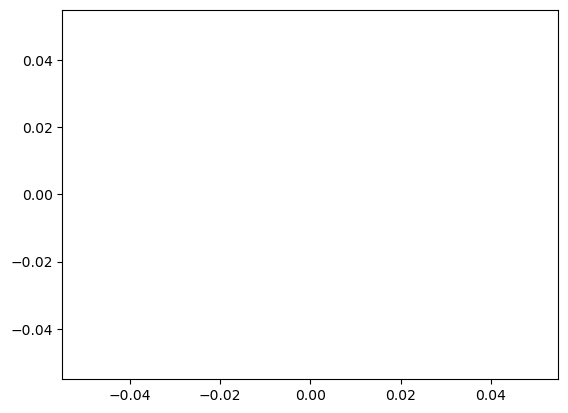

In [79]:
x = df.drop('Outcome',axis=1)
y = df['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac=[]
for i in range(40,70):
    RF = RandomForestClassifier(criterion='entropy',random_state=42,n_estimators=51)
    RF.fit(x_train,y_train)
    y_pred = RF.predict(x_test)
    ac.append(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))
plt.plot()

In [103]:
import pandas as pd
df = pd.read_csv('titanic.csv')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [105]:
df = df.drop(['name','ticket','cabin'],axis=1)

In [106]:
df.isna().sum()

pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64

In [107]:
df.embarked = df.embarked.fillna(df.embarked.mode()[0])

In [108]:
df = df.fillna(df.mean(numeric_only=True))

In [109]:
y = df['survived']
x = df.drop('survived',axis=1)

In [110]:
x = pd.get_dummies(x)
x

,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1,29.000000,0,0,211.3375,True,False,False,False,True
1,1,0.916700,1,2,151.5500,False,True,False,False,True
2,1,2.000000,1,2,151.5500,True,False,False,False,True
3,1,30.000000,1,2,151.5500,False,True,False,False,True
4,1,25.000000,1,2,151.5500,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
1304,3,14.500000,1,0,14.4542,True,False,True,False,False
1305,3,29.881135,1,0,14.4542,True,False,True,False,False
1306,3,26.500000,0,0,7.2250,False,True,True,False,False
1307,3,27.000000,0,0,7.2250,False,True,True,False,False


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [112]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_knn=0
for i in range(27,45):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_knn:
        ac_knn=ac
        neighbour=i
print(ac,",",neighbour)

0.6526717557251909 , 39


In [113]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_dt=0
for i in range(1,50):
    dt = DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=i)
    dt.fit(x_train,y_train)
    y_pred = dt.predict(x_test)
    ac = accuracy_score(y_test,y_pred)
    if ac>ac_dt:
        ac_dt=ac
        depth=i
print(ac_dt,",",i)

0.7786259541984732 , 49


[Text(0.4762067938021454, 0.9864864864864865, 'sex_female <= 0.5\nentropy = 0.947\nsamples = 1047\nvalue = [665, 382]'),
 Text(0.17410607866507746, 0.9594594594594594, 'age <= 9.5\nentropy = 0.667\nsamples = 677\nvalue = [559, 118]'),
 Text(0.32515643623361146, 0.972972972972973, 'True  '),
 Text(0.04576877234803337, 0.9324324324324325, 'sibsp <= 2.5\nentropy = 0.971\nsamples = 35\nvalue = [14, 21]'),
 Text(0.030512514898688916, 0.9054054054054054, 'fare <= 15.573\nentropy = 0.559\nsamples = 23\nvalue = [3, 20]'),
 Text(0.022884386174016686, 0.8783783783783784, 'fare <= 13.125\nentropy = 0.954\nsamples = 8\nvalue = [3, 5]'),
 Text(0.015256257449344458, 0.8513513513513513, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.030512514898688916, 0.8513513513513513, 'age <= 6.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.022884386174016686, 0.8243243243243243, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.03814064362336114, 0.8243243243243243, 'entropy = 0.0\nsampl

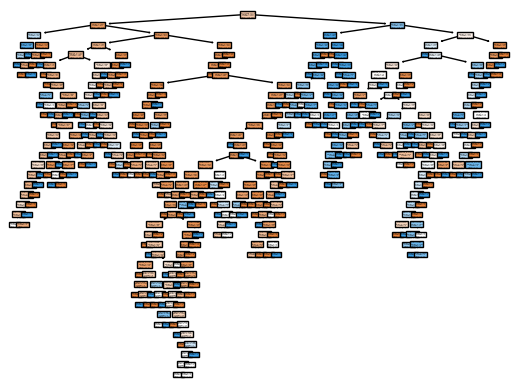

In [114]:
from sklearn.tree import plot_tree
plot_tree(dt,feature_names=x.columns,filled=True)

In [75]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_rf=0
for i in range(30,100):
    rf = RandomForestClassifier(n_estimators=i,criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred = rf.predict(x_test)
    ac = accuracy_score(y_test,y_pred)
    if ac>ac_rf:
        ac_rf=ac
        n=i
print(ac_rf,",",n)

0.7938931297709924 , 45


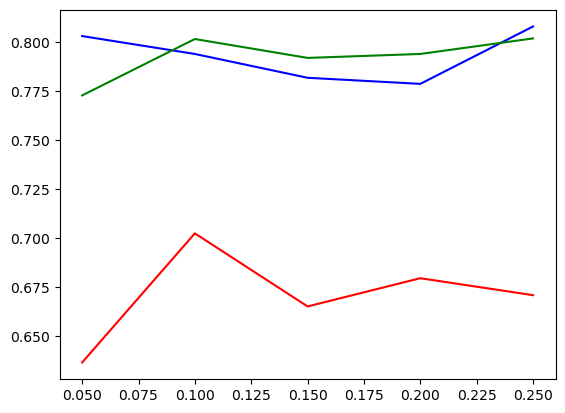

In [115]:
ac_knn=[]
ac_dt=[]
ac_rf=[]
test = [0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=42)
    
    knn=KNeighborsClassifier(n_neighbors=39)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    ac_knn.append(accuracy_score(y_test,y_pred))

    dt = DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=3)
    dt.fit(x_train,y_train)
    y_pred = dt.predict(x_test)
    ac_dt.append(accuracy_score(y_test,y_pred))

    rf = RandomForestClassifier(n_estimators=45,criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred = rf.predict(x_test)
    ac_rf.append(accuracy_score(y_test,y_pred))

plt.plot(test,ac_knn,color='red')
plt.plot(test,ac_dt,color='blue')
plt.plot(test,ac_rf,color='green')

In [116]:
from sklearn.datasets import load_iris
x = load_iris()

In [ ]:
y=load_iris.